# Climate Change Data Analysis

Course: DAT4004-S2-23 ??
Author: Tom Rowan, st20285213
Tutor: Priya

## Introduction

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

*The objective of the proposed data analysis tasks is to provide up-to-date and meaningful analysis that will help users to inform decisions on future policy and services.*

---

## Import Libraries

In [22]:
# Install Requirements Using Pip
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [249]:
# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# SciKit Learn
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

# Seaborn Graphs
import seaborn as sns

# Plotly
import chart_studio
import plotly.figure_factory as ff
import chart_studio.plotly as py
import plotly.graph_objects as go
import plotly.express as px

# Other Standard Libraries
import os
import re
import json
from urllib import request
from tabulate import tabulate
import math
import statistics


### Check for Internet Connectivity

A free account is required to utilise PlotLy graphs, and will require live Internet access to run this notebook properly.

If you are not online, the notebook will display pre-generated png files of the intended output for these graphs.

In [24]:
online = False

def check_internet():
    try:
        request.urlopen('http://connectivitycheck.gstatic.com/generate_204', timeout=3)
        return True
    except request.URLError as err:
        return False
    
if check_internet() == True:
    print ("We are online. :)")
    online = True

    url_prefix = "https://datascience.daemonchild.com/year1/dat4004/"
    
    # Initialise Plotly with credentials
    plotly_username = 'st20285213' 
    plotly_key = 'WiFyUClTkfEwCduNDlpU'     # <-- Note to self, regenerate new key after August 2024
    chart_studio.tools.set_credentials_file(username=plotly_username, api_key=plotly_key)

    #countries_csv_url = "https://raw.githubusercontent.com/daemonchild/dat4004-data-science-fundamentals/main/datasets/countries/world-regions-according-to-the-world-bank.csv?token=GHSAT0AAAAAACQ44HN4VOT45G7DEZRN6NOEZSGEINA"
    #dev_indic_csv_url = "https://raw.githubusercontent.com/daemonchild/dat4004-data-science-fundamentals/main/datasets/wbank_dev_indicators/38b7cb7a-172f-4be9-a48d-34d89fca9fc9_Data.csv?token=GHSAT0AAAAAACQ44HN46SJCSXTOOET6PM6YZSGGJ6A"

else:
    print ("No internet connection, will use pre-generated graphs/tables.")
    url_prefix = "../datasets/"

We are online. :)


---

# Task 1 - Import and Preprocess Data Sets

Task 1:
- i.	Download the dataset from the above link. 
- ii.	Do the necessary preprocessing for example i.e., check for any null value or outlier. If found replace that with mean value and delete repeating factors as necessary.


Reference: https://databank.worldbank.org/reports.aspx?source=2&Topic=19#advancedDownloadOptions

Accessed: 10/05/2024

Reference: https://ourworldindata.org/world-region-map-definitions

Accessed:  15/05/2024



## UNSD Countries and Region Dataset

The United Nations provides a simple dataset which classifies each country by region. This data will be used to enrich analysis of the main datasets.

To explore the relative size of the regions, I have performed counting operations, and plotted the results. The data is relatively clean and requires only the removal of non-relevant columns. The country names in this data set are 'better' than those in the World Bank datasets, and this data includes regions ("Americas") and subregions ("Northern Europe") that can be mapped to countries in the World Bank dataset. This will give two levels of aggregation - global regions, and subregions.

Dataset source: https://unstats.un.org/unsd/methodology/m49/overview/

Note that it is not possible to provide a link directly to a csv file due to the download process on this page.

I have put the dataset online here: https://datascience.daemonchild.com/year1/dat4004/datasets/unsd/unsd-countrycodes.csv

In [25]:
# Load Data Set
_csv_url = f"{url_prefix}datasets/unsd/unsd-countrycodes.csv"
print (f"Loading data from {_csv_url}")
countries_df = pd.read_csv(_csv_url, delimiter=";")

# Rename Columns
countries_df.rename(columns={'Country or Area': 'Country', 'Region Name': 'Region', 'ISO-alpha3 Code': 'ISOcode','Sub-region Name': 'Subregion','Intermediate Region Name': 'Intregion'}, inplace=True)

# Fill in blanks with a zero.
countries_df = countries_df.fillna(0)

countries_df.columns


Loading data from https://datascience.daemonchild.com/year1/dat4004/datasets/unsd/unsd-countrycodes.csv


Index(['Global Code', 'Global Name', 'Region Code', 'Region',
       'Sub-region Code', 'Subregion', 'Intermediate Region Code', 'Intregion',
       'Country', 'M49 Code', 'ISO-alpha2 Code', 'ISOcode',
       'Least Developed Countries (LDC)',
       'Land Locked Developing Countries (LLDC)',
       'Small Island Developing States (SIDS)'],
      dtype='object')

In [26]:
# The subregion and intermediate regions are combined, using the more localised 'Intermediate region' in preference.
countries_df['Intregion'] = np.where(countries_df['Intregion'] == 0, countries_df['Subregion'], countries_df['Intregion'])

# Remove the Subregion column and all others not required, and rename  Intregion
countries_df = countries_df.loc[:, ['Country','Region','ISOcode','Intregion']]
countries_df.rename(columns={'Intregion': 'Subregion'}, inplace=True)

# Manually Label Antartica for completeness; there should be no data anyway (in theory).
countries_df.loc[countries_df['Country'] == "Antarctica", "Region"] = "Antarctica"
countries_df.loc[countries_df['Country'] == "Antarctica", "Subregion"] = "Antarctica"

In [27]:
# Produce Lists
countries = list(countries_df['Country'].astype(str).unique())
regions = list(countries_df['Region'].astype(str).unique())
subregions = list(countries_df['Subregion'].astype(str).unique())
country_codes = list(countries_df['ISOcode'].astype(str).unique())

# Sort these...

print (f"Regions ({len(regions)}): {regions}")
print ()
print (f"Subregions ({len(subregions)}): {subregions}")
print ()
print (f"Countries ({len(countries)}): {countries}")

Regions (6): ['Africa', 'Americas', 'Antarctica', 'Asia', 'Europe', 'Oceania']

Subregions (23): ['Northern Africa', 'Eastern Africa', 'Middle Africa', 'Southern Africa', 'Western Africa', 'Caribbean', 'Central America', 'South America', 'Northern America', 'Antarctica', 'Central Asia', 'Eastern Asia', 'South-eastern Asia', 'Southern Asia', 'Western Asia', 'Eastern Europe', 'Northern Europe', 'Southern Europe', 'Western Europe', 'Australia and New Zealand', 'Melanesia', 'Micronesia', 'Polynesia']

Countries (248): ['Algeria', 'Egypt', 'Libya', 'Morocco', 'Sudan', 'Tunisia', 'Western Sahara', 'British Indian Ocean Territory', 'Burundi', 'Comoros', 'Djibouti', 'Eritrea', 'Ethiopia', 'French Southern Territories', 'Kenya', 'Madagascar', 'Malawi', 'Mauritius', 'Mayotte', 'Mozambique', 'Réunion', 'Rwanda', 'Seychelles', 'Somalia', 'South Sudan', 'Uganda', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe', 'Angola', 'Cameroon', 'Central African Republic', 'Chad', 'Congo', 'Democratic Repub

In [28]:
# Show link between region and subregion
print ("Regions and Subregion members (in rows):")
subregion_gb = countries_df.groupby(by=['Region'])
print (tabulate(subregion_gb.Subregion.unique()))

print ("Subregions per Region")
region_count_table = countries_df[['Country','Region']].groupby(['Region'])['Country'].count()
print (region_count_table)
print ()
print ("Countries per Subregion")
subregion_count_table = countries_df[['Country','Subregion']].groupby(['Subregion'])['Country'].count()
print (subregion_count_table)




Regions and Subregion members (in rows):
----------  -------------------------  ---------------  ------------------  ----------------  --------------
Africa      Northern Africa            Eastern Africa   Middle Africa       Southern Africa   Western Africa
Americas    Caribbean                  Central America  South America       Northern America
Antarctica  Antarctica
Asia        Central Asia               Eastern Asia     South-eastern Asia  Southern Asia     Western Asia
Europe      Eastern Europe             Northern Europe  Southern Europe     Western Europe
Oceania     Australia and New Zealand  Melanesia        Micronesia          Polynesia
----------  -------------------------  ---------------  ------------------  ----------------  --------------
Subregions per Region
Region
Africa        60
Americas      57
Antarctica     1
Asia          50
Europe        51
Oceania       29
Name: Country, dtype: int64

Countries per Subregion
Subregion
Antarctica                    1
Austra

Graphing this data:

Text(0, 0.5, 'Number of Countries')

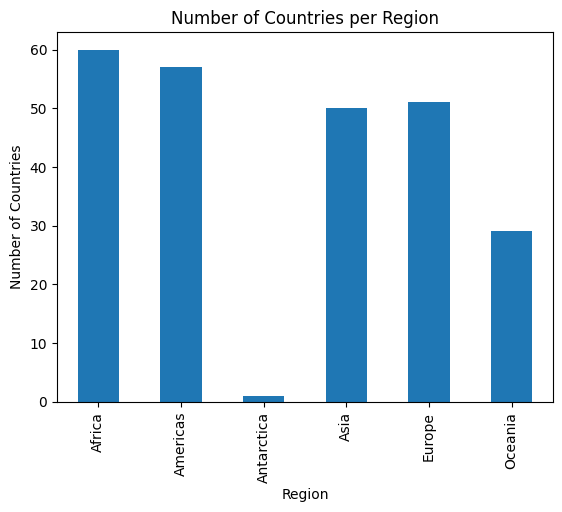

In [29]:
region_count_graph = region_count_table.plot(kind='bar', title='Number of Countries per Region', stacked=True)
region_count_graph.set_xlabel('Region')
region_count_graph.set_ylabel('Number of Countries')

Text(0, 0.5, 'Number of Countries')

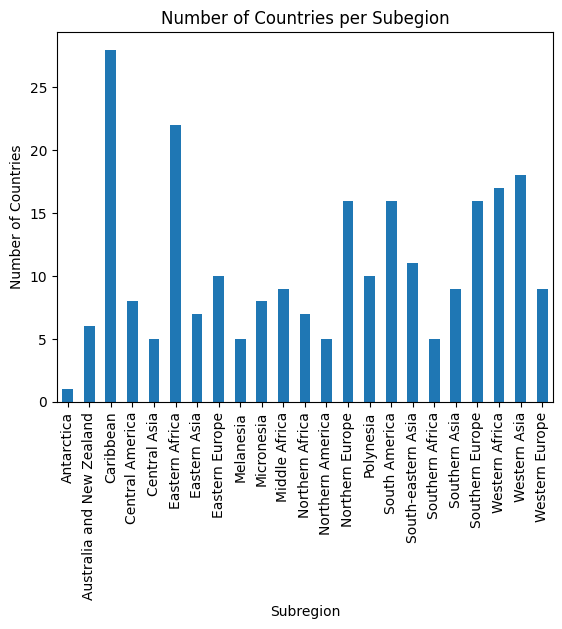

In [30]:
subregion_count_graph = subregion_count_table.plot(kind='bar', title='Number of Countries per Subegion', stacked=True)
subregion_count_graph.set_xlabel('Subregion')
subregion_count_graph.set_ylabel('Number of Countries')

### Mapping these Regions



In [230]:
#fig = px.choropleth(country_data_df, locations='ISOcode', color='Region', hover_name='Region',
                    #projection='equirectangular', title='Sub-region Groupings')
#fig.show()

In [231]:
fig = px.choropleth(country_data_df, locations='ISOcode', color='Subregion', hover_name='Subregion',
                    projection='equirectangular', title='Sub-region Groupings')
fig.show()

Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| countries_df | Country,Code,Region | Pandas DF |
| countries | Country Names | List |
| regions | Region Names | List |
| subregions | Subregion Names | List |
| country_codes | Country Codes | List |

## World Bank Development Indicator Data

I am attempting to explore how land usage affects climate change. The World Bank Development Indicators dataset includes use of land, electricity generation methods and volumes of CO2 produced by source.

In [32]:
# Load Data Set - Bottom 5 rows are blank or not data.
_csv_url = f"{url_prefix}datasets/wb/P_Data_Extract_From_World_Development_Indicators.csv"
print (f"Loading data from {_csv_url}")
devindic_df = pd.read_csv(_csv_url,skipfooter=5, engine='python')

# Drop columns with No data
devindic_df.drop("2022 [YR2022]",axis=1,inplace=True)
devindic_df.drop("2023 [YR2023]",axis=1,inplace=True)
devindic_df.columns

Loading data from https://datascience.daemonchild.com/year1/dat4004/datasets/wb/P_Data_Extract_From_World_Development_Indicators.csv


Index(['Series Name', 'Series Code', 'Country Name', 'Country Code',
       '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]',
       '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]',
       '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]',
       '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]',
       '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]',
       '2020 [YR2020]', '2021 [YR2021]'],
      dtype='object')

In [33]:
# Rename Columns to more useful names
numerical_fields = [str(x).zfill(2) for x in range(2000,2022)]
string_fields = ["SeriesName", "SeriesCode", "Country_WB", "ISOcode"]   # <-- Country_WB for WorldBank name, allows merge later
devindic_df.columns = (string_fields + numerical_fields)

devindic_df.columns


Index(['SeriesName', 'SeriesCode', 'Country_WB', 'ISOcode', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021'],
      dtype='object')

In [34]:
# Define lists
series_codes = (list(devindic_df['SeriesCode'].astype(str).unique()))
series_names = (list(devindic_df['SeriesName'].astype(str).unique()))


### Series Code Analysis

Here I am investating the series code. It is made up of a number of tokens which identify the dataset purpose. Understanding this code will allow easier searching of the data series for relevant data.

In [35]:

# Extract Dataset containing Series Information
series_data_df= pd.DataFrame()
series_data_df['SeriesCode'] = devindic_df['SeriesCode'].unique()
series_data_df['SeriesName'] = devindic_df['SeriesName'].unique()

series_data_df = series_data_df.sort_values(by='SeriesCode')

print (tabulate(series_data_df, tablefmt="pipe", headers="keys"))


|    | SeriesCode           | SeriesName                                                                                      |
|---:|:---------------------|:------------------------------------------------------------------------------------------------|
|  0 | AG.LND.AGRI.K2       | Agricultural land (sq. km)                                                                      |
|  1 | AG.LND.AGRI.ZS       | Agricultural land (% of land area)                                                              |
| 41 | AG.LND.ARBL.HA       | Arable land (hectares)                                                                          |
|  2 | AG.LND.ARBL.ZS       | Arable land (% of land area)                                                                    |
| 66 | AG.LND.CREL.HA       | Land under cereal production (hectares)                                                         |
| 69 | AG.LND.CROP.ZS       | Permanent cropland (% of land area)                                       

**edit me!**

Create a Unit column by splitting the "SeriesName" column - the name of the series - into two parts.

For example "Agricultural land (sq. km)" becomes SeriesName: "Agricultural Land", Unit: "SQ. KM".

In [36]:
# https://stackoverflow.com/questions/13784192/creating-an-empty-pandas-dataframe-and-then-filling-it
# Building into a list first as per ^

_temp_list = []

for _index, _row in series_data_df.iterrows():

    _code_tokens = _row['SeriesCode'].split(".")
    _num_tokens = len(_code_tokens)
    
    if _num_tokens == 3:
        _row['UnitCode'] = "--"
    elif _num_tokens == 4:
        _row['TypeCode'] = '-'.join(map(str,_code_tokens[1:3]))
        _row['UnitCode'] = _code_tokens[-1]  
    else:
        _row['UnitCode'] = _code_tokens[-1]
        _row['TypeCode'] = '-'.join(map(str,_code_tokens[1:(_num_tokens-2)]))

    _row['StudyCode']= _code_tokens[0]

    _name_tokens = _row['SeriesName'].split("(")
    if len(_name_tokens)> 1:
        _row['GraphUnit'] = _name_tokens[1].rstrip(")").upper()
    else:
        _row['GraphUnit'] = "People"
    _temp_list.append(_row)

# Finally replace into series_data_df
series_data_df = pd.DataFrame(_temp_list)




In [37]:
print (tabulate(series_data_df, tablefmt="pipe", headers="keys"))

|    | SeriesCode           | SeriesName                                                                                      | TypeCode    | UnitCode   | StudyCode   | GraphUnit                              |
|---:|:---------------------|:------------------------------------------------------------------------------------------------|:------------|:-----------|:------------|:---------------------------------------|
|  0 | AG.LND.AGRI.K2       | Agricultural land (sq. km)                                                                      | LND-AGRI    | K2         | AG          | SQ. KM                                 |
|  1 | AG.LND.AGRI.ZS       | Agricultural land (% of land area)                                                              | LND-AGRI    | ZS         | AG          | % OF LAND AREA                         |
| 41 | AG.LND.ARBL.HA       | Arable land (hectares)                                                                          | LND-ARBL    | HA         | AG   

In [38]:
# Drop Series Name from one table
series_data_df.drop(['SeriesName'], axis=1, inplace=True)

# Back fill from the series analysis above

_columns_to_merge = series_data_df.columns.difference(devindic_df.columns)
devindic_df = pd.merge(devindic_df, series_data_df, on=["SeriesCode"], how='left')

print(devindic_df.columns)

type(devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"])


Index(['SeriesName', 'SeriesCode', 'Country_WB', 'ISOcode', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', 'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit'],
      dtype='object')


pandas.core.frame.DataFrame

In [39]:
print(devindic_df.shape)

(23142, 30)


In [40]:
devindic_df.tail()

,SeriesName,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,TypeCode,UnitCode,StudyCode,GraphUnit
23137,Total fisheries production (metric tons),ER.FSH.PROD.MT,Sub-Saharan Africa,SSF,5199488.91,5297800.56,5347826.83,5614839.25,5811742.65,5767348.54,...,7431838.25,7974276.35,7895407.33,7961915,7826265.76,8180272.73,FSH-PROD,MT,ER,METRIC TONS
23138,Total fisheries production (metric tons),ER.FSH.PROD.MT,Sub-Saharan Africa (excluding high income),SSA,5166285.91,5243927.56,5284209.83,5527735.25,5709896.65,5657896.54,...,7304290.5,7831623.18,7748783.85,7819745.6,7686618.17,8041098.57,FSH-PROD,MT,ER,METRIC TONS
23139,Total fisheries production (metric tons),ER.FSH.PROD.MT,Sub-Saharan Africa (IDA & IBRD countries),TSS,5199488.91,5297800.56,5347826.83,5614839.25,5811742.65,5767348.54,...,7431838.25,7974276.35,7895407.33,7961915,7826265.76,8180272.73,FSH-PROD,MT,ER,METRIC TONS
23140,Total fisheries production (metric tons),ER.FSH.PROD.MT,Upper middle income,UMC,71078889.4,69156430.7,71856148.68,71218867.45,77202528.29,78992995.91,...,99408754.95,101594266.52,106297663.06,105787856.91,108038766.6,111435146.39,FSH-PROD,MT,ER,METRIC TONS
23141,Total fisheries production (metric tons),ER.FSH.PROD.MT,World,WLD,137012144.68,136763113.54,140159792.35,140238806.47,149082261.24,151975436.07,...,197685290.2,205148563.7,211435206.37,211656620.38,212154014.94,216872257.81,FSH-PROD,MT,ER,METRIC TONS


The dataset contains a large number of elements where there is a null value; where there is no recorded data. This has been recorded in the dataset as a '..' value, and the datatype of the columns were consequently marked as 'object', rather than a float value during the CSV import. This indicates an unreported value for a given year.

In review of the data, there are also some zero values in the data (see next cell). These appear to be used interchanegably with the "..". For the purposes of this study, unreported figures and zero figures are equivalent, as a zero figure is, in most cases, highly unlikely excepting small island nations.

In [41]:
# Showing a line in the dataset with multiple '..' values:
devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]

,SeriesName,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,TypeCode,UnitCode,StudyCode,GraphUnit
983,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,Sudan,SDN,16.91787254253,..,..,..,..,..,...,..,..,..,..,..,..,LND-EL5M,K2,AG,SQ. KM


In [42]:
# Replacing the ".." marker in all numerical data columns.
for column in numerical_fields:
    devindic_df[column] = devindic_df[column].replace("..","0")

In [43]:
# Showing the same line in the dataset:
devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]

,SeriesName,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,TypeCode,UnitCode,StudyCode,GraphUnit
983,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,Sudan,SDN,16.91787254253,0,0,0,0,0,...,0,0,0,0,0,0,LND-EL5M,K2,AG,SQ. KM


## Joining UNSD and WorldBank Tables

I am merging the tables based on the ISOcode for the country.

In [44]:
country_data_df = pd.merge( devindic_df, countries_df, on=["ISOcode"], how='left')

# Remove the World Bank Country Name
country_data_df.drop(columns=['Country_WB'], inplace=True)

Set Column Types now that we have built the entire dataframe.

In [45]:

# Generate a list of the non-numerical column names
print (f"{string_fields} --> ", end="")
string_fields = [sf for sf in country_data_df.columns if sf not in numerical_fields]
print (string_fields)

for column in string_fields:
   country_data_df[column] = country_data_df[column].astype(str)

for column in numerical_fields:
   country_data_df[column] = country_data_df[column].astype(float)

country_data_df.dtypes

# Write out to CSV
country_data_df.to_csv("../outputs/wb_merged_unsd_on_isocode.csv", sep=',', encoding='utf-8')

['SeriesName', 'SeriesCode', 'Country_WB', 'ISOcode'] --> ['SeriesName', 'SeriesCode', 'ISOcode', 'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit', 'Country', 'Region', 'Subregion']


### Separate Aggregated Data
As well as data for distinct countries, the World Bank dataset also includes data from aggregated regions. This data can be extracted from the working data set and saved for later use. The Kosovo country code is not found in the UNSD data. It is an empty row and can also be removed, as shown from this extract from the CSV:

> Agricultural Land,AG.LND.AGRI.K2,Kosovo,XKX,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..

To do this, I am using the country_codes extracted from the UNSD dataset, and using the intersection between the "ISOcode" column to filter the data into two dataframes. I have saved these to CSV once completed.

In [46]:
# Extract Regional Data (NB if NOT in)
regional_data_only_df = pd.DataFrame(country_data_df[~country_data_df['ISOcode'].isin(country_codes)])
#regional_data_only_df[["ISOcode","Country"]].drop_duplicates(inplace=True)
regional_data_only_df.to_csv("../outputs/wb_regional_data_discarded.csv")

# Country Data
country_data_df = pd.DataFrame(country_data_df[country_data_df['ISOcode'].isin(country_codes)])
country_data_df.to_csv("../outputs/country_data.csv")


This dataset comprises multiple subtables of unrelated data concatenated, sharing the same column names. The Series Code is the key to each sub-table, each containing a complete set of records for each country. To confirm:

In [47]:
# Number of records per dataset, also equals the number of countries
country_data_df.groupby(['SeriesCode'])['Country'].count().head(3)

SeriesCode
AG.LND.AGRI.K2    215
AG.LND.AGRI.ZS    215
AG.LND.ARBL.HA    215
Name: Country, dtype: int64

In [48]:
country_data_df.columns

Index(['SeriesName', 'SeriesCode', 'ISOcode', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit', 'Country', 'Region',
       'Subregion'],
      dtype='object')

In [49]:
print(country_data_df.shape)

(18705, 32)


In [50]:
#To extract an individual sub table, the following example can be used:
    
df_AG_LND_AGRI_K2 = country_data_df.loc[country_data_df['SeriesCode'] == "AG.LND.AGRI.K2"]
df_AG_LND_AGRI_K2.columns

Index(['SeriesName', 'SeriesCode', 'ISOcode', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit', 'Country', 'Region',
       'Subregion'],
      dtype='object')

Define a graph function to plot each series.

In [51]:
def plot_data_series_years (dataframe, ylabel="y axis", title="a graph", start=2000, end=2021, log=0):

    _range = [str(x).zfill(2) for x in range(start,end+1)]
    _years = pd.Index(_range)

    for _index, _row in dataframe.iterrows():
        _country = _row['Country']
        _country_data = _row[_years]

        # There *will* be divide by zero errors, trying to trap, but ensure that we fill with a true zero.
        if log == 10:
            _country_data = np.log10(_country_data.astype(float), out=np.zeros_like(_country_data), where=(_country_data>0.0))
        elif log == 2:
            _country_data = np.log2(_country_data.astype(float), out=np.zeros_like(_country_data), where=(_country_data>0.0))
        
        plt.plot(_years,_country_data,label=_country)

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    #plt.legend(loc="upper left")   <-- Too big!

    fig = plt.gcf()
    fig.set_size_inches(6, 4, forward=True)

    plt.show()

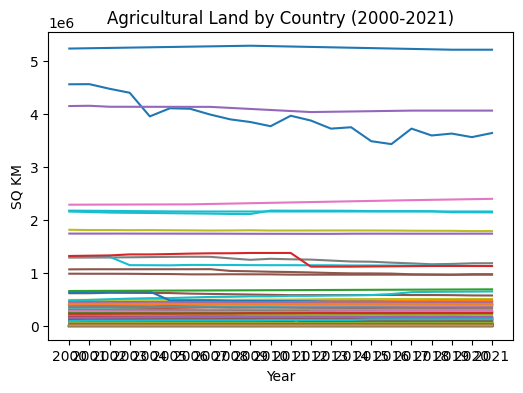

/Users/tom/LocalDevelopment/dat4004-data-science-fundamentals/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tom/LocalDevelopment/dat4004-data-science-fundamentals/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tom/LocalDevelopment/dat4004-data-science-fundamentals/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tom/LocalDevelopment/dat4004-data-science-fundamentals/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tom/LocalDevelopment/dat4004-data-science-fundamentals/.venv/lib/

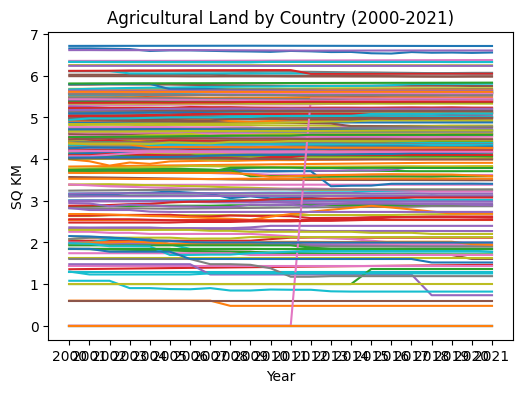

In [52]:
# Using df_AG_LND_AGRI_K2, Agricultural Land by Country (2000-2021)
plot_data_series_years (dataframe=df_AG_LND_AGRI_K2, ylabel="SQ KM", title="Agricultural Land by Country (2000-2021)", start=2000, end=2021)
plot_data_series_years (dataframe=df_AG_LND_AGRI_K2, ylabel="SQ KM", title="Agricultural Land by Country (2000-2021)", start=2000, end=2021, log=10)

Using the function, I will now plot all the data series in turn to ascertain the shape of the dataset graphically.

In [53]:
# NB run time approx: 55 sec

def get_unit (dataframe):
    return str(dataframe["GraphUnit"].unique()[0])

def get_seriesname (dataframe):
    return str(dataframe["SeriesName"].unique()[0])

for _series in data_series_list:
    _series_data = country_data_df.loc[country_data_df['SeriesCode'] == _series]
    _unit = get_unit(_series_data)
    _series_name = get_seriesname (_series_data)
    _title = str(_series_name + "(" +_unit+ ")")
    #plot_data_series_years (dataframe=_series_data, title=_title, ylabel=_unit)

NameError: name 'data_series_list' is not defined

This is clearly an unsuitable plot for clearly showing this data, (even using logarithmic values). However, these plots how the general 'shape' of the data sets for future reference. It will be useful to add a units column to each series.

Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| country_data_df| Country,Code,SeriesCode,{Data Values} | Pandas DF |
| regional_data_only_df | Country,Code,SeriesCode,{Data Values} | Pandas DF |


---

# Task 2 - Data Analysis



## Rank regions by CO2 emissions. Who is worst?

In this question, I will utilise data on total $CO_{2}$ emissions.

I will first group the data by subregion, then sum the total emissions for each subregion. Once ordered by this sum, the rank can be assigned, in decending order (where highest value = rank 1, next highest = 2).

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
EN.ATM.CO2E.KT | CO2 Emissions | Tons x 10^3 (KT)

In [227]:
# Extract C02 data for all, then extract westrn european figures
co2data_df = country_data_df.loc[country_data_df['SeriesCode'] == 'EN.ATM.CO2E.KT'].dropna()

# Remove 2021 - it's empty for all countries
co2data_df.drop('2021', axis=1, inplace=True)
co2_data_num_fields = numerical_fields.copy()
co2_data_num_fields.remove("2021")


As an initial review, I have mapped the data at the extremes of the data range - 2000 and 2020 - to review changes over the time series. From these maps, it's clear to see two facts:

- Global Emissions have increased. The scale of the legend on the maps demonstrates this clearly.
- The leader board of emitters has changed over time. 

In [233]:

fig = px.choropleth(co2data_df, locations='ISOcode', color='2000', hover_name='Country',
                    projection='equirectangular', title='CO2 Emissions by Country 2000')
fig.show()

In [232]:

fig = px.choropleth(co2data_df, locations='ISOcode', color='2020', hover_name='Country',
                    projection='equirectangular', title='CO2 Emissions by Country 2020')
fig.show()


To create the ranking table, first I will create totals for $CO_{2}$, grouped by Subregion and plot this data in it's raw form.

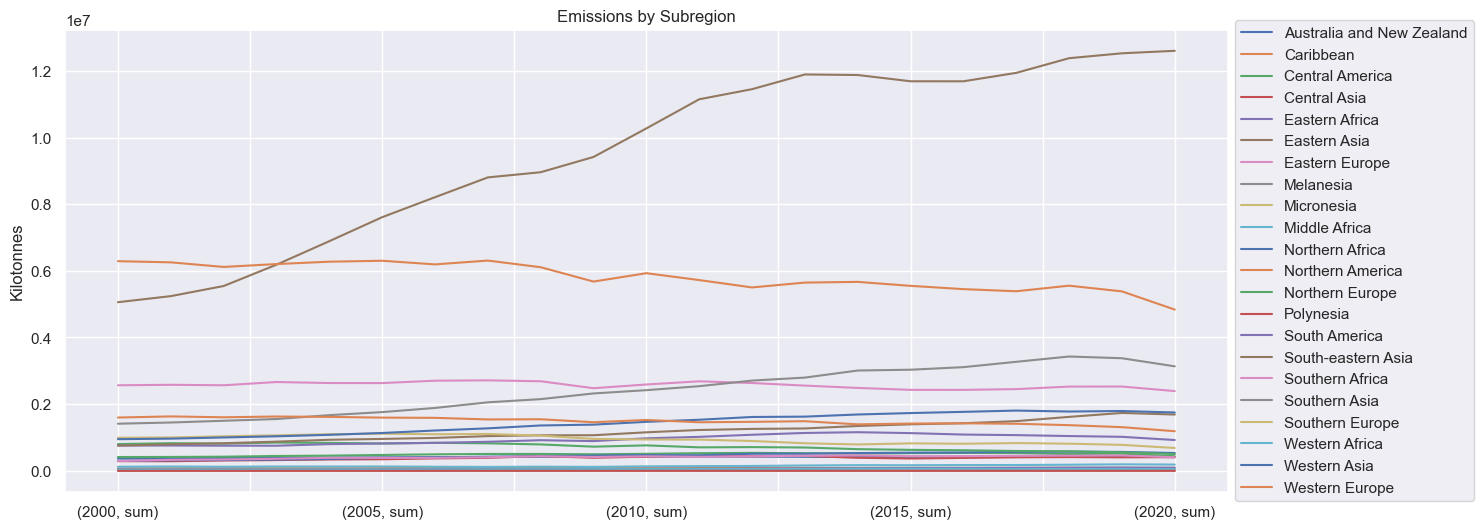

In [280]:
#Extract Data
co2data_subregion_gb = co2data_df.groupby(by='Subregion')[co2_data_num_fields].agg(['sum'])

# Create plot
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes", title="Total CO2 Emissions by Subregion");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

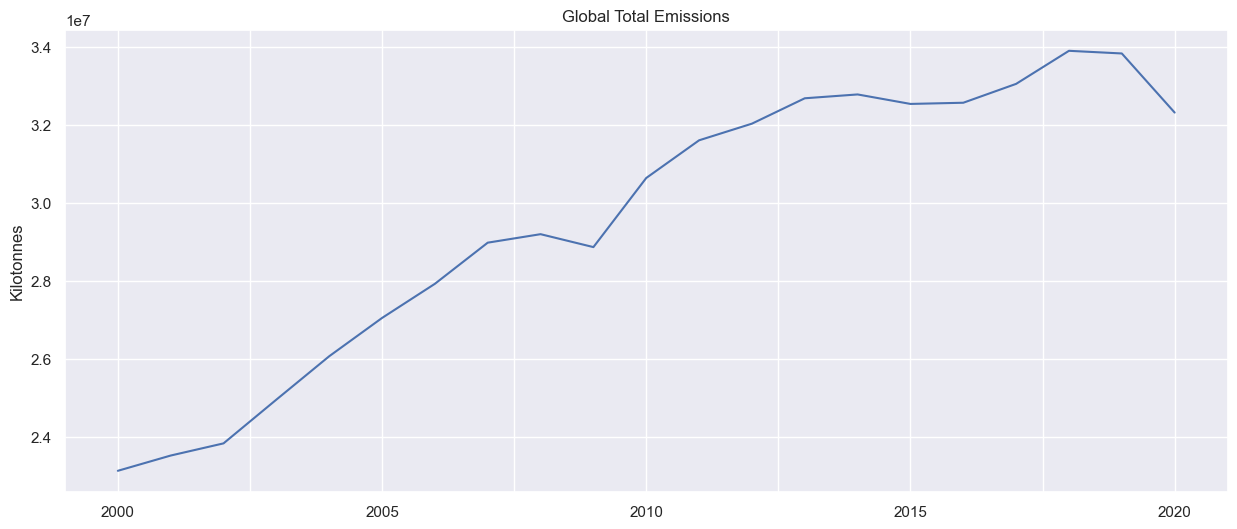

In [307]:
# Total CO2 emissions over time:
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb_log = co2data_df.groupby(by='Subregion')[co2_data_num_fields].sum().apply(['sum'])
co2data_subregion_gb_log.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes",title="Global Total Emissions",legend=False);
plt.show();

Extract Mean value for $CO_{2}$ by Region, to gain insight into whether a subregion is the highest producer, on average. This takes into account that some regions may include high volume emitters *and* at the same time include very low level emitters. This shows that Northern America has been consistenly a higher producer - on average - for longer than Eastern Asia.

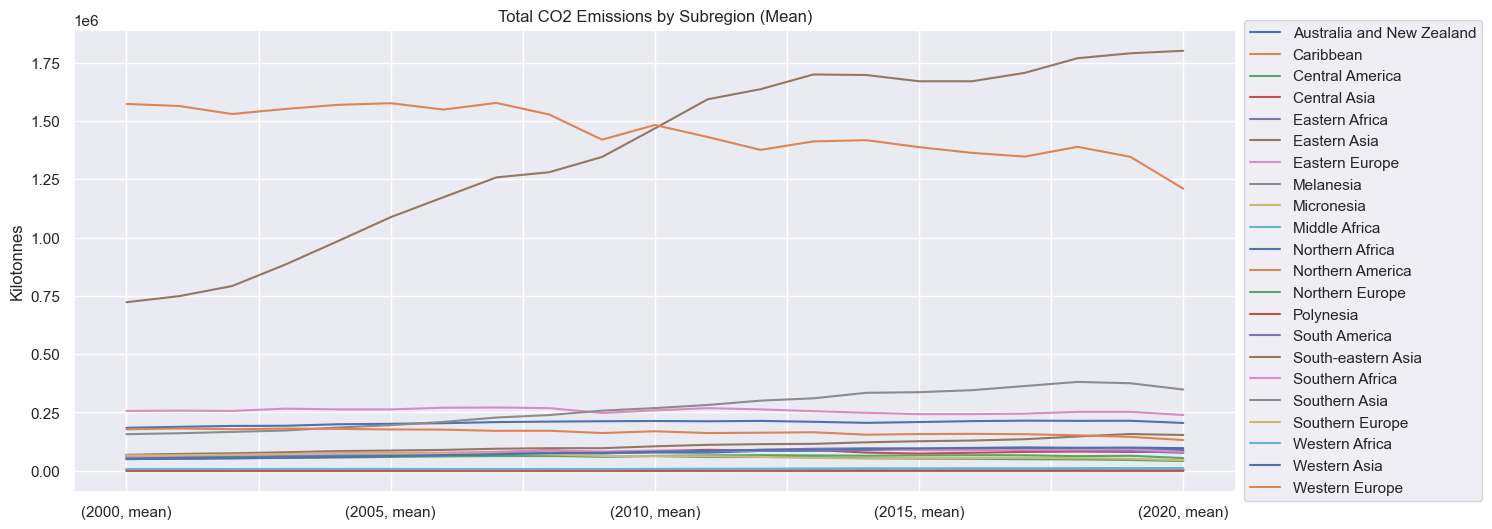

In [308]:
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb_mean = co2data_df.groupby(by='Subregion')[co2_data_num_fields].agg(['mean'])
co2data_subregion_gb_mean.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes", title="Total CO2 Emissions by Subregion (Mean)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()


To compare the values on a line graph requires a logarithmic scale. I will sum and then perform a $\log_{10}$ operation to allow for comparison between regions. Using this plot, we can see that there is a lot of movement over twenty years, thus the ranking table will be produced on a an annual basis.

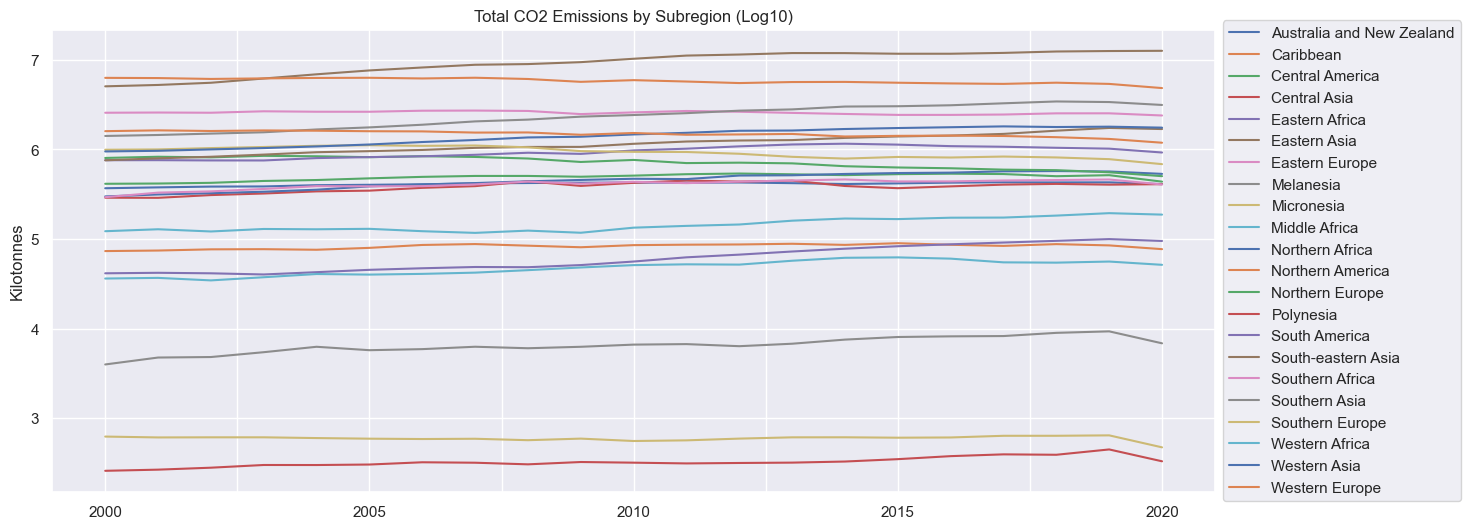

In [309]:
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb_log = co2data_df.groupby(by='Subregion')[co2_data_num_fields].sum().apply(lambda x: np.log10(x))
co2data_subregion_gb_log.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes",title="Total CO2 Emissions by Subregion (Log10)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show();





The question asks who are the worst CO~2~ emitters. The graphs above clearly show that some regions are increasing their emissions, while others are reducing. A heatmap is another way of clearly showing the worst polluters, over time:

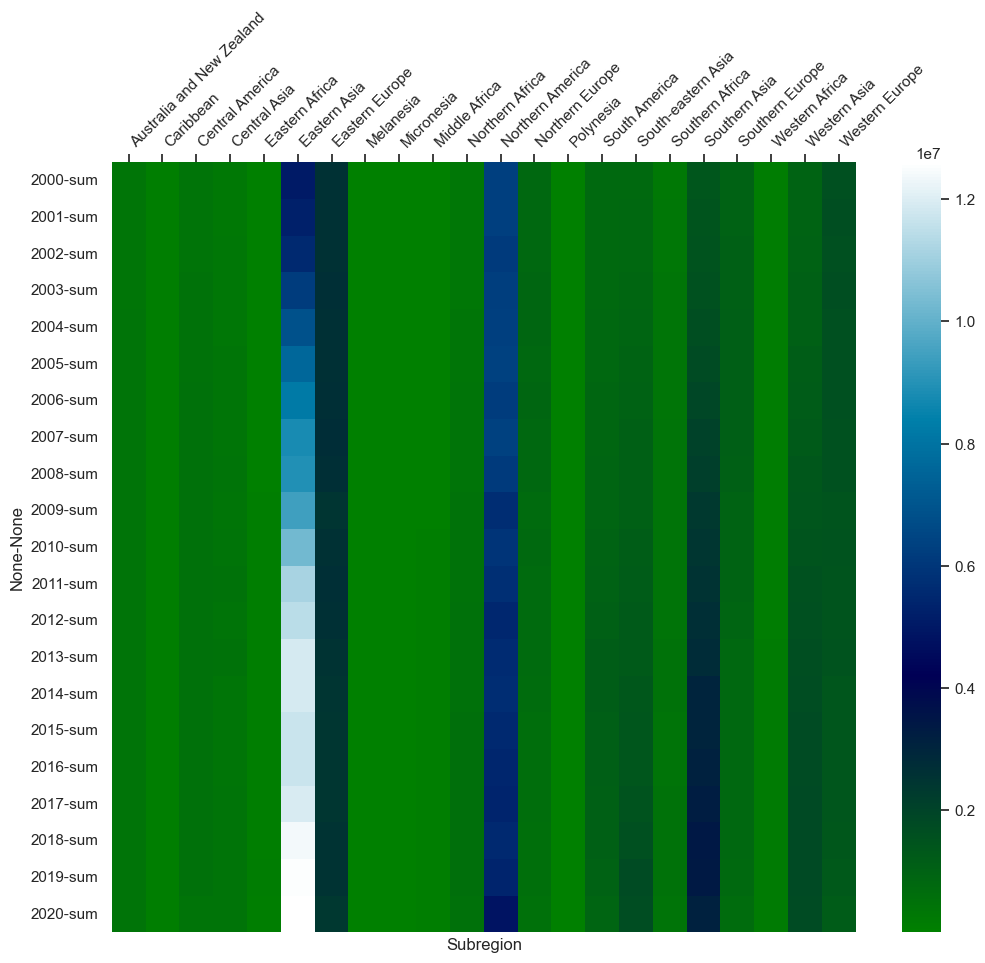

In [340]:
sns.set_theme()
plt.figure(figsize=(12, 10))
ax = sns.heatmap(co2data_subregion_gb.transpose(),cmap="ocean");
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.xaxis.tick_top() 


### Produce Ranking Table

To create a clear ranking table and plot, I will use a groupby with a sum, and then ranking.

In [311]:
# Build empty DataFrame, using appropriate year fields list
co2_subregion_rank_df = pd.DataFrame(columns=co2_data_num_fields)

# Build a ranking for each year in turn, and add to th eoutput dataframe
for _year in co2_data_num_fields:
    _new_df = co2data_df.groupby(by='Subregion')[_year].agg(['sum']).sort_values(by='sum', ascending=False).rank(ascending=False)
    co2_subregion_rank_df[_year] = _new_df

print(co2_subregion_rank_df)



                           2000  2001  2002  2003  2004  2005  2006  2007  \
Subregion                                                                   
Northern America            1.0   1.0   1.0   1.0   2.0   2.0   2.0   2.0   
Eastern Asia                2.0   2.0   2.0   2.0   1.0   1.0   1.0   1.0   
Eastern Europe              3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   
Western Europe              4.0   4.0   4.0   4.0   5.0   5.0   5.0   5.0   
Southern Asia               5.0   5.0   5.0   5.0   4.0   4.0   4.0   4.0   
Southern Europe             6.0   6.0   6.0   6.0   6.0   7.0   7.0   7.0   
Western Asia                7.0   7.0   7.0   7.0   7.0   6.0   6.0   6.0   
Northern Europe             8.0   8.0   9.0   9.0   9.0  10.0   9.0  10.0   
South America               9.0  10.0  10.0  10.0  10.0   9.0  10.0   9.0   
South-eastern Asia         10.0   9.0   8.0   8.0   8.0   8.0   8.0   8.0   
Central America            11.0  11.0  11.0  11.0  11.0  11.0  11.0  11.0   

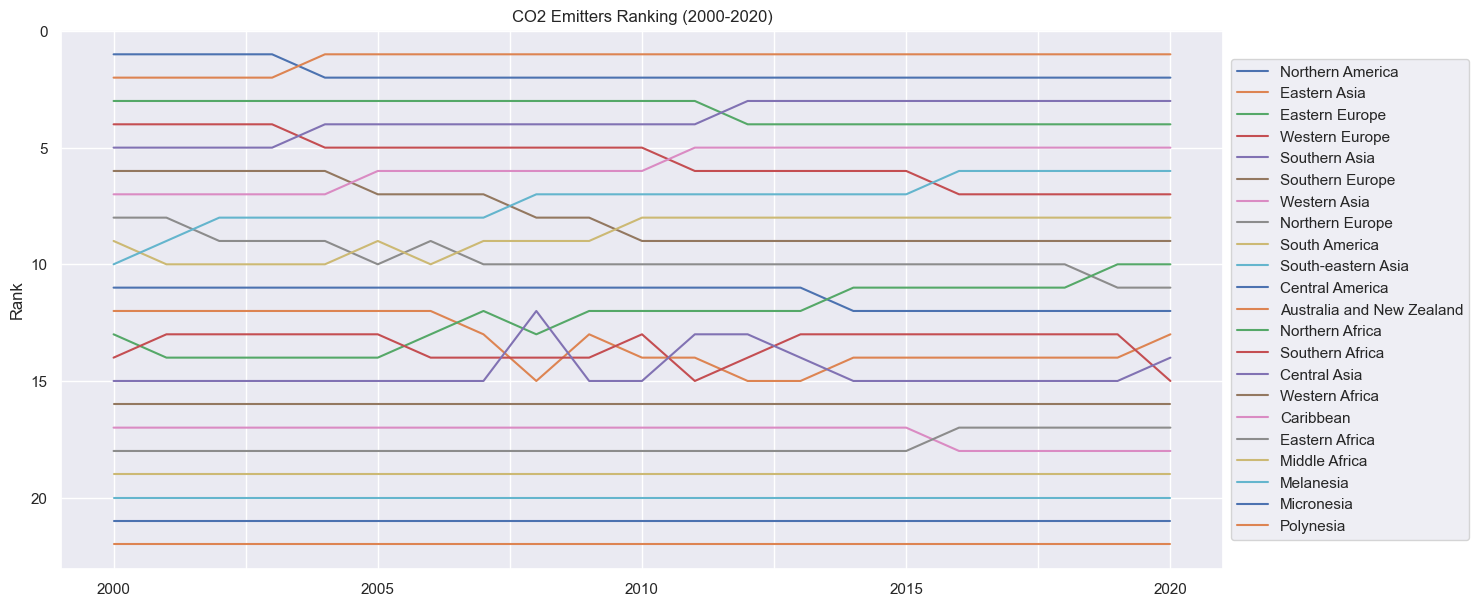

In [297]:
# Finally plot ranking over time.
fig, ax = plt.subplots(figsize=(15,7))
co2_subregion_rank_df.transpose().plot(kind='line', ax=ax, ylabel="Rank", title="CO2 Emitters Ranking (2000-2020)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.gca().invert_yaxis()
plt.show();

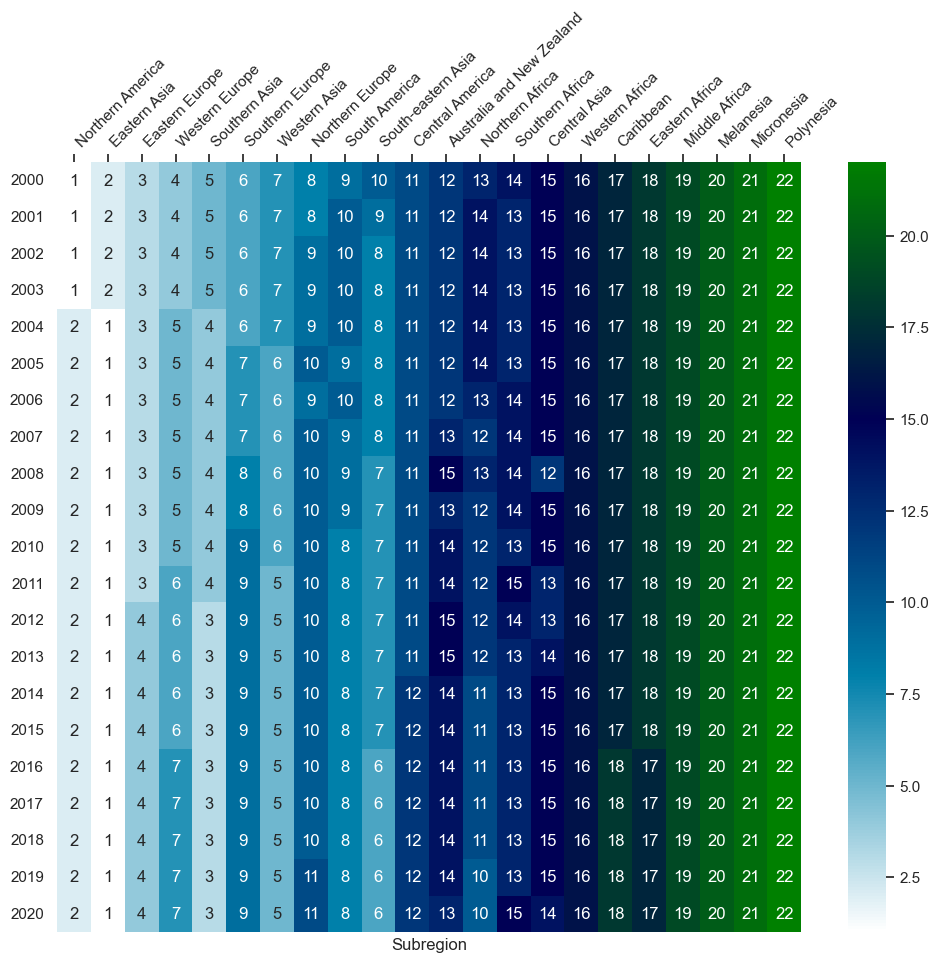

In [339]:
sns.set_theme()
plt.figure(figsize=(12, 10))
ax = sns.heatmap(co2_subregion_rank_df.transpose(),cmap="ocean_r",annot=True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.xaxis.tick_top() 
plt.show()

It is also easy to produce a country rank table, although this will be limited to the Top 20 worst $CO_{2}$ polluters. This limit will create holes in the data where countries drop out of this ranking, and no data for those replacing them.

In [312]:
# Build empty DataFrame, using appropriate year fields list
co2_country_rank_df = pd.DataFrame(columns=co2_data_num_fields)

# Build a ranking for each year in turn, and add to th eoutput dataframe
for _year in co2_data_num_fields:
    _new_df = co2data_df.groupby(by='Country')[_year].agg(['sum']).sort_values(by='sum', ascending=False).rank(ascending=False).head(20)
    co2_country_rank_df[_year] = _new_df

print(co2_country_rank_df)

                                                    2000  2001  2002  2003  \
Country                                                                      
United States of America                             1.0   1.0   1.0   1.0   
China                                                2.0   2.0   2.0   2.0   
Russian Federation                                   3.0   3.0   3.0   3.0   
Japan                                                4.0   4.0   4.0   4.0   
India                                                5.0   5.0   5.0   5.0   
Germany                                              6.0   6.0   6.0   6.0   
United Kingdom of Great Britain and Northern Ir...   7.0   7.0   7.0   8.0   
Canada                                               8.0   8.0   8.0   7.0   
Republic of Korea                                    9.0   9.0   9.0   9.0   
Italy                                               10.0  10.0  10.0  10.0   
Mexico                                              11.0  11.0  

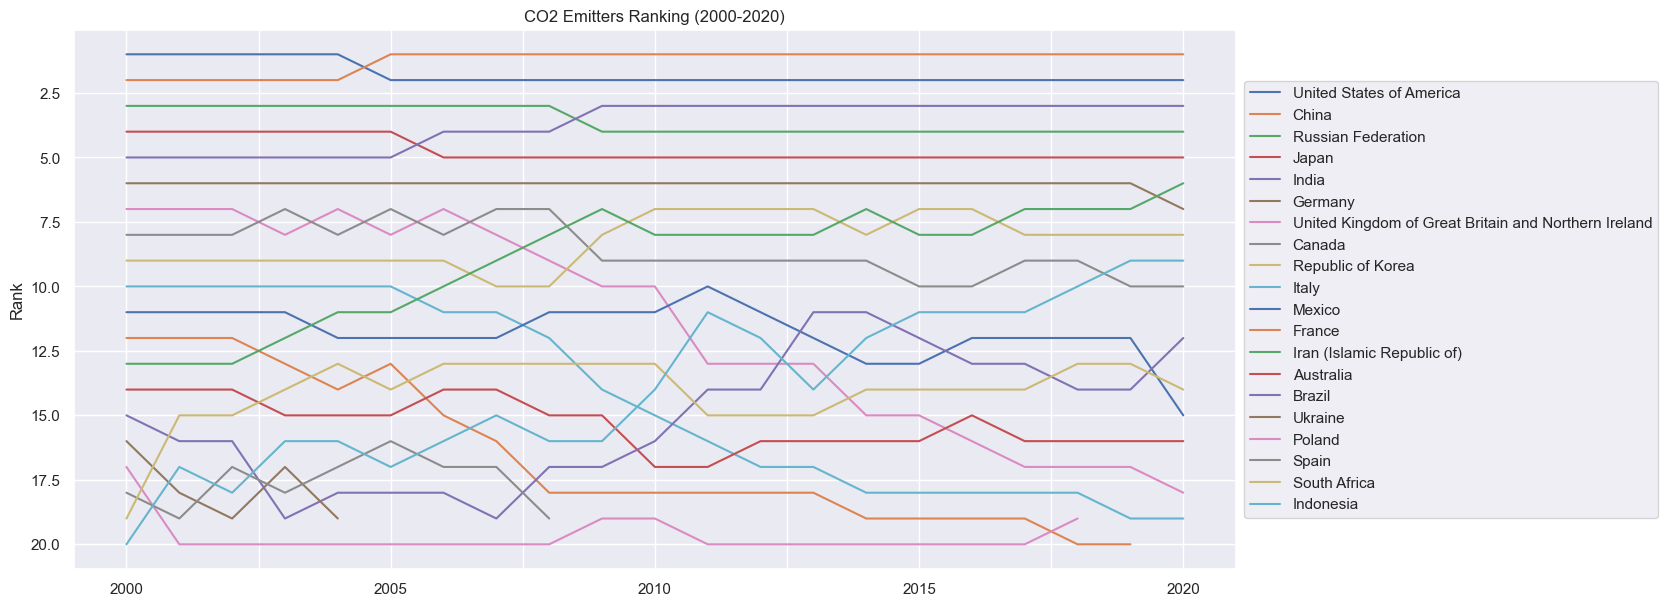

In [313]:
fig, ax = plt.subplots(figsize=(15,7))
co2_country_rank_df.transpose().plot(kind='line', ax=ax, ylabel="Rank", title="CO2 Emitters Ranking (2000-2020)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.gca().invert_yaxis()
plt.show();

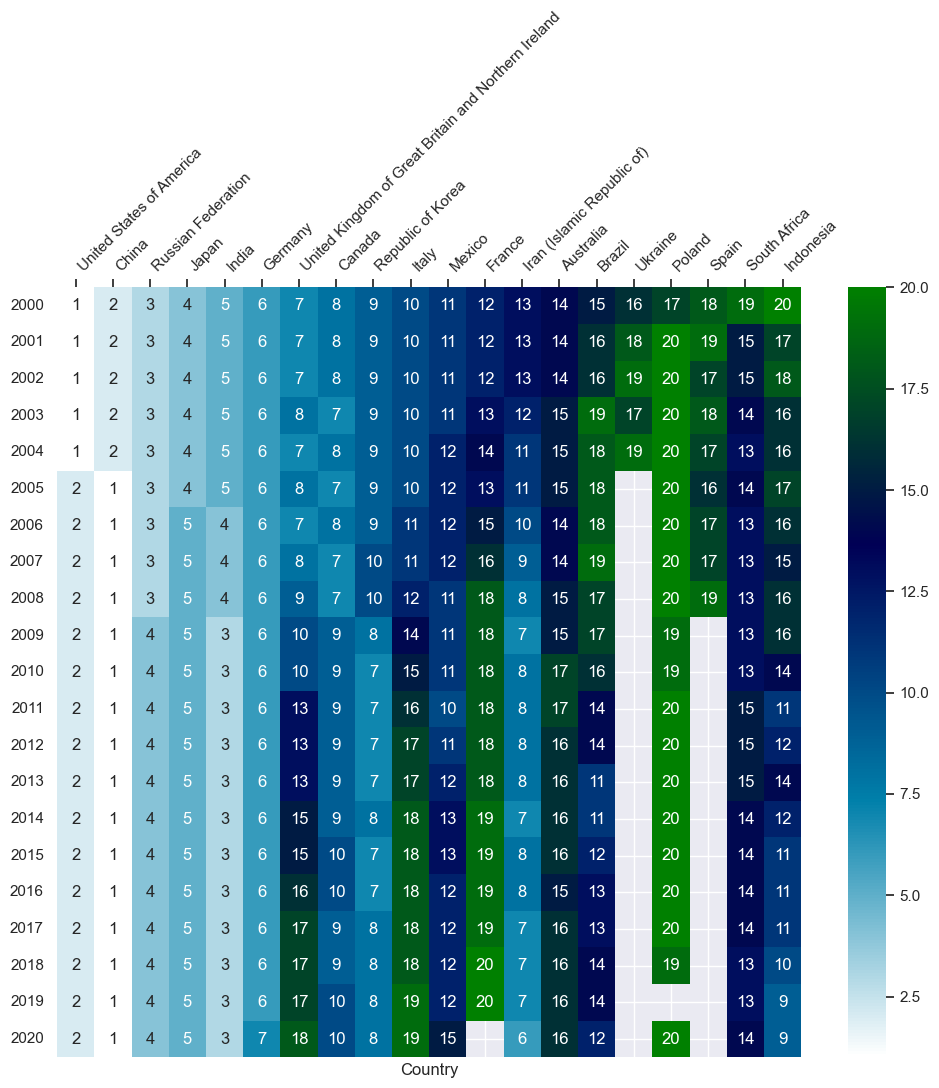

In [338]:
sns.set_theme()
plt.figure(figsize=(12, 10))
ax = sns.heatmap(co2_country_rank_df.transpose(),cmap="ocean_r",annot=True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.xaxis.tick_top() 
plt.show()

---
## Is there a link to population and birth-rate to CO2 emmissions?




---

Task 2. Data analysis (LO2, LO3)
Formulate data analysis questions which could be answered by analysing your chosen dataset. For each question provide graph/chart along with your own interpretation. Please find the sample data analysis questions formulated for the ONS census dataset.

### Task Questions

The datasets available from the World Bank are extensive. I have collected together a wide selection of 

- Rank regions by CO2 emissions. Who is worst? 

- Which type of land usage generates the most CO2?
- Describe the change is land use by country, and by world region.
- Describe trends in land use by region. (hmm.)
- Predict how countries CO2 emmissions will trend over time.
- Rank regions by CO2 emissions. Who is worst?
- Is there a link to population and birth-rate CO2 emmissions?
- Are CO2 emissions increasing over time?
- Eletricial consumption over time vs renewables, by region?

what insights.... is there corrolation.... renable vs Co2.

What should policy makers do with this information...?

task 3 clustering basedon regression.

CO2 Emissions Data

EN.ATM.CO2E.KT



Playing with charts

In [226]:
# Plot graph of birth and death rates on a world map



df_SP_DYN_CDRT_IN = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.DYN.CDRT.IN']
df_SP_DYN_CBRT_IN = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.DYN.CBRT.IN']

_range = [str(x).zfill(2) for x in range(2000,2021+1)]
_years = pd.Index(_range)



fig = go.Figure(go.Scatter(x=df_SP_DYN_CBRT_IN['2021'], y=df_SP_DYN_CDRT_IN['2021'], text=df_SP_DYN_CDRT_IN.Country, mode='markers'))
#fig.update_xaxes(title_text='GDP per Capita', type='log')
#fig.update_yaxes(title_text='Life Expectancy')
py.iplot(fig, filename='pandas-multiple-scatter')